# 3-Stage Shelf Analysis Pipeline (v2)
## Stage 1: Dense Product Detection (SKU-110K trained YOLOv8)
## Stage 2: Empty Space Detection (custom trained model)
## Stage 3: Product Identification (EasyOCR + Qwen2-VL)

**Models required (upload as Kaggle Datasets):**
- `sku110k_best.pt` - your trained SKU-110K product detector
- `empty_space_best.pt` - your trained empty space detector

**Setup:**
1. Upload both `.pt` files as Kaggle Datasets
2. Update the paths in Cell 3 to match your dataset paths
3. Enable T4 GPU in notebook settings
4. Run all cells in order

**Test image sources (Cell 4):**
- Default: SKU110K annotations dataset from Kaggle
- Optional: Roboflow API (set USE_ROBOFLOW = True when API key is working)


In [36]:
# ============================================================
# Cell 1: Install & verify GPU
# ============================================================
!pip install -q ultralytics easyocr roboflow
!pip install -q transformers accelerate bitsandbytes pillow qwen-vl-utils

import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


PyTorch: 2.10.0+cu128
CUDA: True
GPU: Tesla T4
VRAM: 15.6 GB


In [37]:
# ============================================================
# Cell 2: Imports
# ============================================================
import os, json, csv, glob, hashlib, shutil
import numpy as np
import cv2
from pathlib import Path
from datetime import datetime
from typing import List, Dict, Optional
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
OUTPUT_DIR = "/kaggle/working/pipeline_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Device: {DEVICE}")
print(f"Output: {OUTPUT_DIR}")


Device: cuda
Output: /kaggle/working/pipeline_output


In [ ]:
# ============================================================
# Cell 3: Load detection models
# ============================================================
# UPDATE THESE PATHS to match your Kaggle dataset uploads
from ultralytics import YOLO

# ── Product detector (SKU-110K trained) ──
# Upload your sku110k_best.pt as a Kaggle Dataset, then use the path below
PRODUCT_MODEL_PATH = "/kaggle/input/models/kushalchhetri07/product-detection/other/default/1/best product detection.pt"  # <-- UPDATE THIS

# ── Empty space detector ──
EMPTY_MODEL_PATH = "/kaggle/input/models/kushalchhetri07/shruti-model/other/default/1/best (1).pt"  # <-- UPDATE THIS

# Load both models
product_detector = YOLO(PRODUCT_MODEL_PATH)
print(f"Product detector loaded: {PRODUCT_MODEL_PATH}")
print(f"  Classes: {product_detector.names}")

empty_detector = YOLO(EMPTY_MODEL_PATH)
print(f"Empty space detector loaded: {EMPTY_MODEL_PATH}")
print(f"  Classes: {empty_detector.names}")


Product detector loaded: /kaggle/input/models/kushalchhetri07/product-detection/other/default/1/best product dtection.pt
  Classes: {0: 'object'}
Empty space detector loaded: /kaggle/input/models/kushalchhetri07/shruti-model/other/default/1/best (1).pt
  Classes: {0: 'empty_space'}


Found 2920 test images
Test image: test_0.jpg
  Products detected: 139
  Empty spaces detected: 6


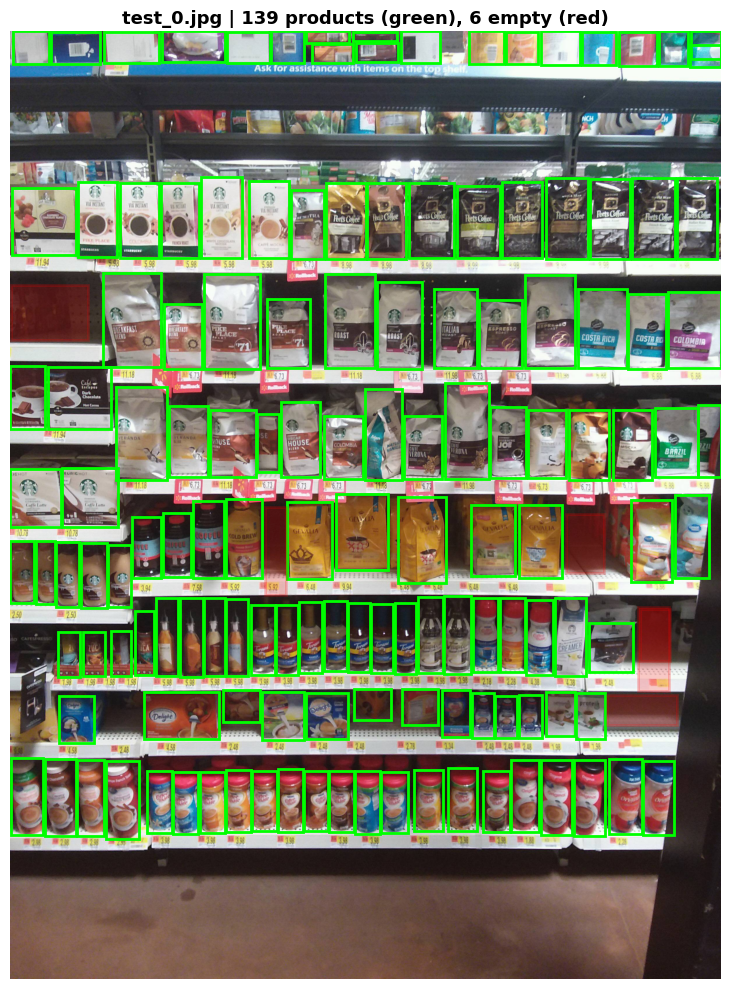

In [ ]:
# ============================================================
# Cell 4: Quick test on a shelf image
# ============================================================
import glob
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ── Toggle: set True to use Roboflow, False for Kaggle SKU110K dataset ──
USE_ROBOFLOW = False
ROBOFLOW_API_KEY = "qD3iNzdjJ3CCYP797XJ9" 

if USE_ROBOFLOW:
    from roboflow import Roboflow
    try:
        rf = Roboflow(api_key=ROBOFLOW_API_KEY)
        project = rf.workspace("jacob-solawetz").project("sku-110k-sxbfq")
        dataset = project.version(2).download("yolov8", location="/kaggle/working/shelf_dataset")
        test_images = sorted(
            glob.glob("/kaggle/working/shelf_dataset/test/images/*.jpg") +
            glob.glob("/kaggle/working/shelf_dataset/test/images/*.png")
        )
        print(f"[Roboflow] Found {len(test_images)} test images")
    except Exception as e:
        print(f"[Roboflow] Failed: {e}")
        print("[Roboflow] Falling back to Kaggle SKU110K dataset...")
        USE_ROBOFLOW = False

if not USE_ROBOFLOW:
    test_images = sorted(glob.glob("/kaggle/input/datasets/thedatasith/sku110k-annotations/SKU110K_fixed/images/test/*.jpg"))
    print(f"[Kaggle SKU110K] Found {len(test_images)} test images")

if test_images:
    img = cv2.cvtColor(cv2.imread(test_images[0]), cv2.COLOR_BGR2RGB)

    results = product_detector.predict(test_images[0], conf=0.25, device=DEVICE, verbose=False)
    n_products = len(results[0].boxes) if results[0].boxes is not None else 0

    results2 = empty_detector.predict(test_images[0], conf=0.1, device=DEVICE, verbose=False)
    n_empty = len(results2[0].boxes) if results2[0].boxes is not None else 0

    print(f"Test image: {os.path.basename(test_images[0])}")
    print(f"  Products detected: {n_products}")
    print(f"  Empty spaces detected: {n_empty}")

    fig, ax = plt.subplots(figsize=(14, 10))
    ax.imshow(img)

    if results[0].boxes is not None:
        for box in results[0].boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                     linewidth=2, edgecolor="lime", facecolor="none")
            ax.add_patch(rect)

    if results2[0].boxes is not None:
        for box in results2[0].boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                     linewidth=2, edgecolor="red", facecolor="red", alpha=0.2)
            ax.add_patch(rect)

    ax.set_title(f"{os.path.basename(test_images[0])} | {n_products} products (green), {n_empty} empty (red)",
                 fontsize=13, fontweight="bold")
    ax.axis("off")
    plt.tight_layout()
    plt.show()


In [40]:
# ============================================================
# Cell 5: Initialize OCR (EasyOCR)
# ============================================================
import easyocr

ocr_reader = easyocr.Reader(['en'], gpu=True)


def extract_text_from_crop(crop_bgr):
    """
    Run EasyOCR on a product crop (BGR numpy array).
    Returns a single string of all detected text, sorted top-to-bottom.
    """
    if crop_bgr is None or crop_bgr.size == 0:
        return ""

    try:
        results = ocr_reader.readtext(crop_bgr)

        if not results:
            return ""

        lines = []
        for (bbox, text, conf) in results:
            if conf > 0.3:
                y_center = (bbox[0][1] + bbox[2][1]) / 2
                lines.append((y_center, text))

        lines.sort(key=lambda x: x[0])
        return " ".join([text for _, text in lines])
    except Exception as e:
        print(f"  OCR error: {e}")
        return ""


print("EasyOCR initialized.")

EasyOCR initialized.


In [41]:
# ============================================================
# Cell 6: Load Qwen2-VL-7B-Instruct (4-bit, ungated, no approval needed)
# ============================================================
import torch
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig

MODEL_ID = "Qwen/Qwen2-VL-7B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)

print("Loading Qwen2-VL-7B (4-bit)... this takes 2-3 minutes.")

vlm_model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16,
)

vlm_processor = AutoProcessor.from_pretrained(MODEL_ID)

print(f"Qwen2-VL loaded. Device: {vlm_model.device}")
print(f"VRAM used: {torch.cuda.memory_allocated() / 1e9:.1f} GB")


[2026-04-07 22:28:17,751] [    INFO] _client.py:1025 - HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2-VL-7B-Instruct/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
[2026-04-07 22:28:17,757] [    INFO] _client.py:1025 - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2-VL-7B-Instruct/eed13092ef92e448dd6875b2a00151bd3f7db0ac/config.json "HTTP/1.1 200 OK"
[2026-04-07 22:28:17,780] [    INFO] _client.py:1025 - HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2-VL-7B-Instruct/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
[2026-04-07 22:28:17,786] [    INFO] _client.py:1025 - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2-VL-7B-Instruct/eed13092ef92e448dd6875b2a00151bd3f7db0ac/config.json "HTTP/1.1 200 OK"
[2026-04-07 22:28:17,807] [    INFO] _client.py:1025 - HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2-VL-7B-Instruct/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
[2026-04-07 22:28:1

Loading Qwen2-VL-7B (4-bit)... this takes 2-3 minutes.


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/730 [00:00<?, ?it/s]

[2026-04-07 22:29:05,830] [    INFO] _client.py:1025 - HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2-VL-7B-Instruct/resolve/main/generation_config.json "HTTP/1.1 307 Temporary Redirect"
[2026-04-07 22:29:05,837] [    INFO] _client.py:1025 - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2-VL-7B-Instruct/eed13092ef92e448dd6875b2a00151bd3f7db0ac/generation_config.json "HTTP/1.1 200 OK"
[2026-04-07 22:29:06,250] [    INFO] _client.py:1025 - HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2-VL-7B-Instruct/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
[2026-04-07 22:29:06,279] [    INFO] _client.py:1025 - HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2-VL-7B-Instruct/resolve/main/preprocessor_config.json "HTTP/1.1 307 Temporary Redirect"
[2026-04-07 22:29:06,285] [    INFO] _client.py:1025 - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2-VL-7B-Instruct/eed13092ef92e448dd6875b2a00151bd3f7db0ac/preprocess

Qwen2-VL loaded. Device: cuda:0
VRAM used: 4.2 GB


In [42]:
# ============================================================
# Cell 7: Product identification via OCR + Qwen2-VL
# ============================================================
import re
import json as json_lib
from qwen_vl_utils import process_vision_info


def identify_product(crop_bgr, ocr_text="", max_new_tokens=150):
    """
    Identify a product from its shelf crop image + OCR text.
    Uses PaddleOCR text + Qwen2-VL vision model.
    """
    crop_rgb = crop_bgr[:, :, ::-1]
    pil_img = Image.fromarray(crop_rgb).convert("RGB")

    if ocr_text.strip():
        user_prompt = (
            f"This is a cropped image of a single product on a grocery store shelf. "
            f'The text visible on the packaging reads: "{ocr_text}". '
            f"Based on the image and text, identify this product. "
            f"Respond with ONLY a JSON object: "
            f'{{"brand": "...", "product_name": "...", "size": "...", "confidence": "high/medium/low"}}'
        )
    else:
        user_prompt = (
            f"This is a cropped image of a single product on a grocery store shelf. "
            f"No text could be read from the packaging. "
            f"Based on the image alone, identify this product as best you can. "
            f"Respond with ONLY a JSON object: "
            f'{{"brand": "...", "product_name": "...", "size": "...", "confidence": "high/medium/low"}}'
        )

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": pil_img},
                {"type": "text", "text": user_prompt},
            ],
        }
    ]

    text = vlm_processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(messages)
    inputs = vlm_processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    ).to(vlm_model.device)

    with torch.no_grad():
        output_ids = vlm_model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)

    generated_ids = output_ids[:, inputs.input_ids.shape[1]:]
    response = vlm_processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()

    return parse_product_response(response, ocr_text)


def parse_product_response(response, ocr_text=""):
    """Parse Qwen2-VL response into a structured product dict."""
    try:
        json_match = re.search(r'\{[^}]+\}', response)
        if json_match:
            data = json_lib.loads(json_match.group())
            return {
                "brand": data.get("brand", "Unknown"),
                "product_name": data.get("product_name", "Unknown"),
                "size": data.get("size", ""),
                "confidence": data.get("confidence", "low"),
                "ocr_text": ocr_text,
                "raw_response": response,
            }
    except (json_lib.JSONDecodeError, AttributeError):
        pass

    return {
        "brand": "Unknown",
        "product_name": response[:100] if response else "Unknown",
        "size": "",
        "confidence": "low",
        "ocr_text": ocr_text,
        "raw_response": response,
    }


print("Product identification functions defined (Qwen2-VL).")


Product identification functions defined (Qwen2-VL).


In [43]:
# ============================================================
# Cell 8: Batch product identification with caching
# ============================================================
product_cache = {}


def get_crop_hash(crop_bgr):
    """Quick hash of a crop for cache lookup."""
    small = cv2.resize(crop_bgr, (32, 32))
    return hashlib.md5(small.tobytes()).hexdigest()


def identify_products_batch(crops_bgr, progress=True):
    """
    Identify a batch of product crops.
    Uses OCR first, then Qwen2-VL, with caching.
    """
    results = []
    cache_hits = 0

    for i, crop in enumerate(crops_bgr):
        if crop is None or crop.size == 0:
            results.append({
                "brand": "Unknown", "product_name": "Unknown",
                "size": "", "confidence": "low", "ocr_text": "",
            })
            continue

        crop_hash = get_crop_hash(crop)
        if crop_hash in product_cache:
            results.append(product_cache[crop_hash])
            cache_hits += 1
            continue

        ocr_text = extract_text_from_crop(crop)
        product_info = identify_product(crop, ocr_text)

        product_cache[crop_hash] = product_info
        results.append(product_info)

        if progress and (i + 1) % 5 == 0:
            print(f"  Identified {i+1}/{len(crops_bgr)} products ({cache_hits} cache hits)")

    if progress:
        print(f"  Done: {len(crops_bgr)} products, {cache_hits} cache hits")

    return results


print("Batch identification with caching ready.")


Batch identification with caching ready.


In [44]:
# ============================================================
# Cell 9: Helper functions (IoU, shelf clustering)
# ============================================================

def compute_iou(a, b):
    xa, ya = max(a["x1"], b["x1"]), max(a["y1"], b["y1"])
    xb, yb = min(a["x2"], b["x2"]), min(a["y2"], b["y2"])
    inter = max(0, xb - xa) * max(0, yb - ya)
    if inter == 0:
        return 0
    area_a = (a["x2"] - a["x1"]) * (a["y2"] - a["y1"])
    area_b = (b["x2"] - b["x1"]) * (b["y2"] - b["y1"])
    return inter / (area_a + area_b - inter)


def cluster_to_shelves(all_dets, products, empties, img_w, img_h):
    if not all_dets:
        return []

    cy_vals = sorted(d["cy"] for d in all_dets)
    bands, cur = [], [cy_vals[0]]
    for cy in cy_vals[1:]:
        if cy - cur[-1] < 0.06:
            cur.append(cy)
        else:
            bands.append(cur)
            cur = [cy]
    bands.append(cur)

    shelf_ranges = []
    for band in bands:
        cy_m = float(np.mean(band))
        band_d = [d for d in all_dets if abs(d["cy"] - cy_m) < 0.08]
        yt = min(d["cy"] - d["h"] / 2 for d in band_d) if band_d else cy_m - 0.05
        yb = max(d["cy"] + d["h"] / 2 for d in band_d) if band_d else cy_m + 0.05
        shelf_ranges.append((max(0, yt), min(1, yb), cy_m))

    merged = [shelf_ranges[0]]
    for yt, yb, cy in shelf_ranges[1:]:
        if abs(cy - merged[-1][2]) < 0.06:
            merged[-1] = (min(merged[-1][0], yt), max(merged[-1][1], yb),
                          (min(merged[-1][0], yt) + max(merged[-1][1], yb)) / 2)
        else:
            merged.append((yt, yb, cy))

    shelves = []
    loc_id = 1
    for si, (yt, yb, cy) in enumerate(merged):
        m = 0.03
        s_prods = sorted([p for p in products if yt - m <= p["cy"] <= yb + m], key=lambda d: d["cx"])
        s_emps = sorted([e for e in empties if yt - m <= e["cy"] <= yb + m], key=lambda d: d["cx"])

        shelf_products = []
        for p in s_prods:
            shelf_products.append({
                "loc_id": loc_id,
                "name": p.get("product_name", "Product"),
                "brand": p.get("brand", ""),
                "ocr_text": p.get("ocr_text", ""),
                "llm_confidence": p.get("llm_confidence", ""),
                "confidence": round(p["confidence"], 3),
                "facings": max(1, round(p["w"] / 0.04)),
                "bbox": {"cx": round(p["cx"], 4), "cy": round(p["cy"], 4),
                         "w": round(p["w"], 4), "h": round(p["h"], 4)},
                "bbox_px": {"x1": p["x1"], "y1": p["y1"], "x2": p["x2"], "y2": p["y2"]},
                "status": "stocked",
            })
            loc_id += 1

        shelf_empties = []
        for e in s_emps:
            shelf_empties.append({
                "loc_id": loc_id,
                "name": e.get("class_name", "empty_space"),
                "confidence": round(e["confidence"], 3),
                "bbox": {"cx": round(e["cx"], 4), "cy": round(e["cy"], 4),
                         "w": round(e["w"], 4), "h": round(e["h"], 4)},
                "bbox_px": {"x1": e["x1"], "y1": e["y1"], "x2": e["x2"], "y2": e["y2"]},
                "status": "empty",
            })
            loc_id += 1

        n = len(shelf_products) + len(shelf_empties)
        shelves.append({
            "shelf_number": si + 1,
            "y_top": round(yt, 4), "y_bottom": round(yb, 4),
            "products": shelf_products,
            "empties": shelf_empties,
            "fill_rate": round(len(shelf_products) / max(1, n), 3),
        })

    return shelves


print("Helper functions defined.")


Helper functions defined.


In [ ]:
# ============================================================
# Cell 10: Full 3-stage pipeline
# ============================================================

def analyze_shelf(image_path, product_conf=0.25, empty_conf=0.1, iou_thresh=0.4):
    """
    3-stage shelf analysis:
    1. SKU-110K model -> find ALL products
    2. Empty space model -> find ALL gaps
    3. PaddleOCR + Qwen2-VL -> identify each product
    """
    img = cv2.imread(image_path)
    h, w = img.shape[:2]

    # ---- Stage 1: Dense product detection ----
    prod_results = product_detector.predict(image_path, conf=product_conf,
                                             device=DEVICE, verbose=False)
    products = []
    if prod_results[0].boxes is not None:
        for box in prod_results[0].boxes:
            x1, y1, x2, y2 = [int(v) for v in box.xyxy[0].tolist()]
            conf = float(box.conf[0])
            products.append({
                "x1": max(0, x1), "y1": max(0, y1), "x2": min(w, x2), "y2": min(h, y2),
                "cx": ((x1 + x2) / 2) / w, "cy": ((y1 + y2) / 2) / h,
                "w": (x2 - x1) / w, "h": (y2 - y1) / h,
                "confidence": conf, "source": "sku110k",
            })

    # ---- Stage 2: Empty space detection ----
    empty_results = empty_detector.predict(image_path, conf=empty_conf,
                                            device=DEVICE, verbose=False)
    empties = []
    if empty_results[0].boxes is not None:
        for box in empty_results[0].boxes:
            x1, y1, x2, y2 = [int(v) for v in box.xyxy[0].tolist()]
            conf = float(box.conf[0])
            cls_id = int(box.cls[0])
            cls_name = empty_detector.names.get(cls_id, "empty_space")
            empties.append({
                "x1": max(0, x1), "y1": max(0, y1), "x2": min(w, x2), "y2": min(h, y2),
                "cx": ((x1 + x2) / 2) / w, "cy": ((y1 + y2) / 2) / h,
                "w": (x2 - x1) / w, "h": (y2 - y1) / h,
                "confidence": conf, "source": "empty", "class_name": cls_name,
            })

    # ---- Resolve overlaps ----
    kept_products = []
    kept_empties = list(empties)
    for p in products:
        overlaps = False
        for i, e in enumerate(kept_empties):
            iou = compute_iou(p, e)
            if iou > iou_thresh:
                overlaps = True
                if p["confidence"] > e["confidence"]:
                    kept_empties.pop(i)
                    kept_products.append(p)
                break
        if not overlaps:
            kept_products.append(p)

    products = kept_products
    empties = kept_empties

    print(f"  Stage 1: {len(products)} products | Stage 2: {len(empties)} empty spaces")

    # ---- Stage 3: OCR + Qwen2-VL ----
    if products:
        print(f"  Stage 3: Identifying {len(products)} products via OCR + Qwen2-VL...")

        crops = []
        for p in products:
            pad_x = int((p["x2"] - p["x1"]) * 0.05)
            pad_y = int((p["y2"] - p["y1"]) * 0.05)
            cx1 = max(0, p["x1"] - pad_x)
            cy1 = max(0, p["y1"] - pad_y)
            cx2 = min(w, p["x2"] + pad_x)
            cy2 = min(h, p["y2"] + pad_y)
            crop = img[cy1:cy2, cx1:cx2]
            crops.append(crop if crop.size > 0 else None)

        identifications = identify_products_batch(crops)

        for p, pid in zip(products, identifications):
            p["product_name"] = f"{pid['brand']} {pid['product_name']}".strip()
            if pid["size"]:
                p["product_name"] += f" ({pid['size']})"
            p["llm_confidence"] = pid["confidence"]
            p["ocr_text"] = pid["ocr_text"]
            p["brand"] = pid["brand"]
            p["identification_method"] = "paddleocr+qwen2vl"

    # ---- Cluster into shelves ----
    all_dets = products + empties
    shelves = cluster_to_shelves(all_dets, products, empties, w, h)

    total_p = sum(len(s["products"]) for s in shelves)
    total_e = sum(len(s["empties"]) for s in shelves)

    return {
        "image": os.path.basename(image_path),
        "width": w, "height": h,
        "total_shelves": len(shelves),
        "total_products": total_p,
        "total_empty": total_e,
        "fill_rate": round(total_p / max(1, total_p + total_e), 3),
        "shelves": shelves,
    }


print("analyze_shelf() defined. Ready to process images.")


analyze_shelf() defined. Ready to process images.


In [46]:
# ============================================================
# Cell 11: Run on shelf images
# ============================================================

# Uses same source as Cell 4 toggle
if USE_ROBOFLOW:
    all_shelf_images = sorted(
        glob.glob("/kaggle/working/shelf_dataset/test/images/*.jpg") +
        glob.glob("/kaggle/working/shelf_dataset/test/images/*.png") +
        glob.glob("/kaggle/working/shelf_dataset/valid/images/*.jpg") +
        glob.glob("/kaggle/working/shelf_dataset/valid/images/*.png")
    )
else:
    all_shelf_images = sorted(glob.glob("/kaggle/input/datasets/thedatasith/sku110k-annotations/SKU110K_fixed/images/test/*.jpg"))

print(f"Total shelf images available: {len(all_shelf_images)}")

# Process first 5 images (adjust as needed)
N_IMAGES = min(5, len(all_shelf_images))
all_results = []

for idx, img_path in enumerate(all_shelf_images[:N_IMAGES]):
    print(f"\n[{idx+1}/{N_IMAGES}] {os.path.basename(img_path)}")
    result = analyze_shelf(img_path)
    all_results.append(result)
    print(f"  Result: {result['total_products']} products, "
          f"{result['total_empty']} empty, fill rate: {result['fill_rate']:.1%}")

print(f"\nProcessed {len(all_results)} images.")


Total shelf images available: 2920

[1/5] test_0.jpg
  Stage 1: 139 products | Stage 2: 6 empty spaces
  Stage 3: Identifying 139 products via OCR + Qwen2-VL...
  Identified 5/139 products (0 cache hits)
  Identified 10/139 products (0 cache hits)
  Identified 15/139 products (0 cache hits)
  Identified 20/139 products (0 cache hits)
  Identified 25/139 products (0 cache hits)
  Identified 30/139 products (0 cache hits)
  Identified 35/139 products (0 cache hits)
  Identified 40/139 products (0 cache hits)
  Identified 45/139 products (0 cache hits)
  Identified 50/139 products (0 cache hits)
  Identified 55/139 products (0 cache hits)
  Identified 60/139 products (0 cache hits)
  Identified 65/139 products (0 cache hits)
  Identified 70/139 products (0 cache hits)
  Identified 75/139 products (0 cache hits)
  Identified 80/139 products (0 cache hits)
  Identified 85/139 products (0 cache hits)
  Identified 90/139 products (0 cache hits)
  Identified 95/139 products (0 cache hits)
  Id

  Saved: /kaggle/working/pipeline_output/annotated_0.png


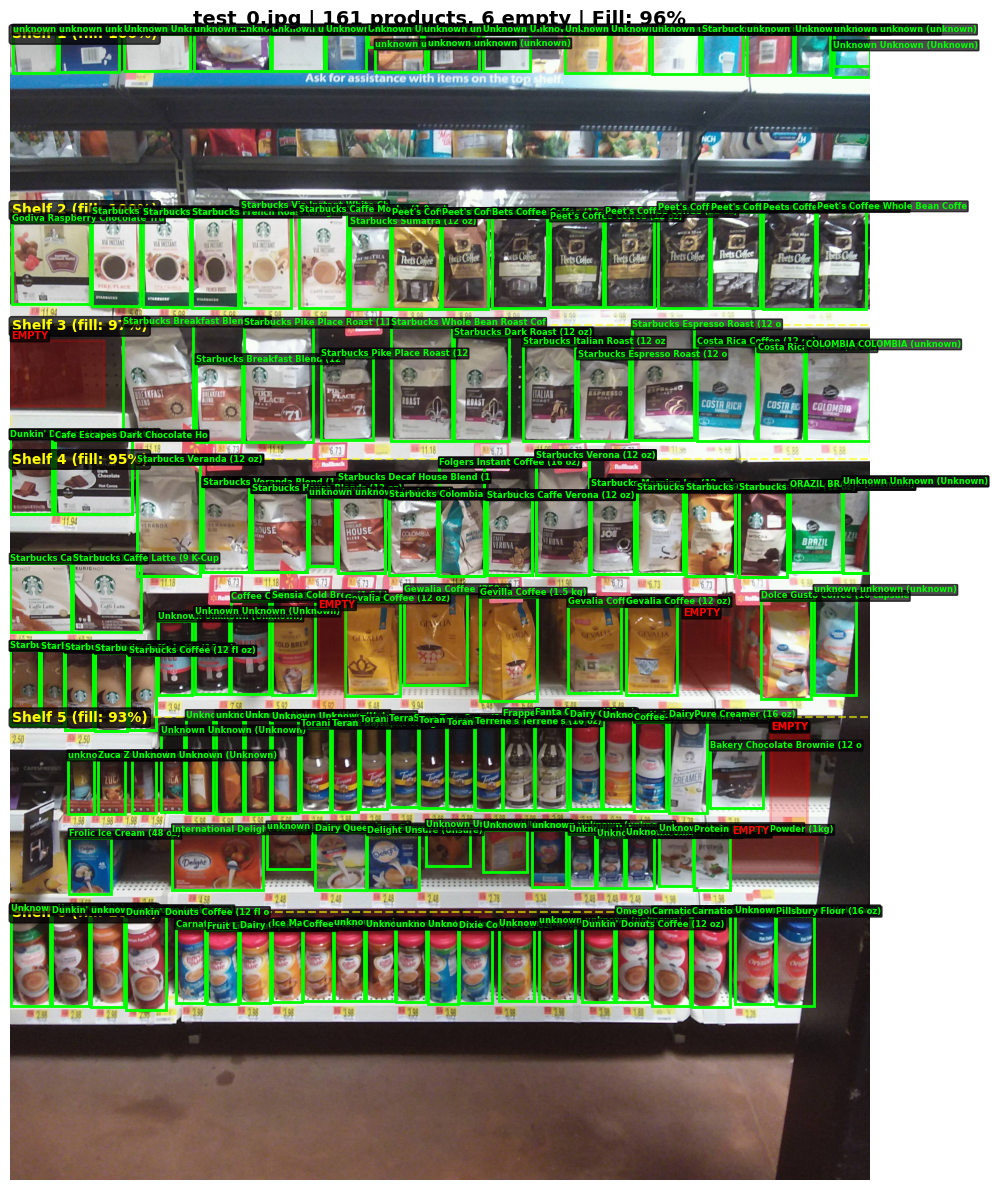

  Saved: /kaggle/working/pipeline_output/annotated_1.png


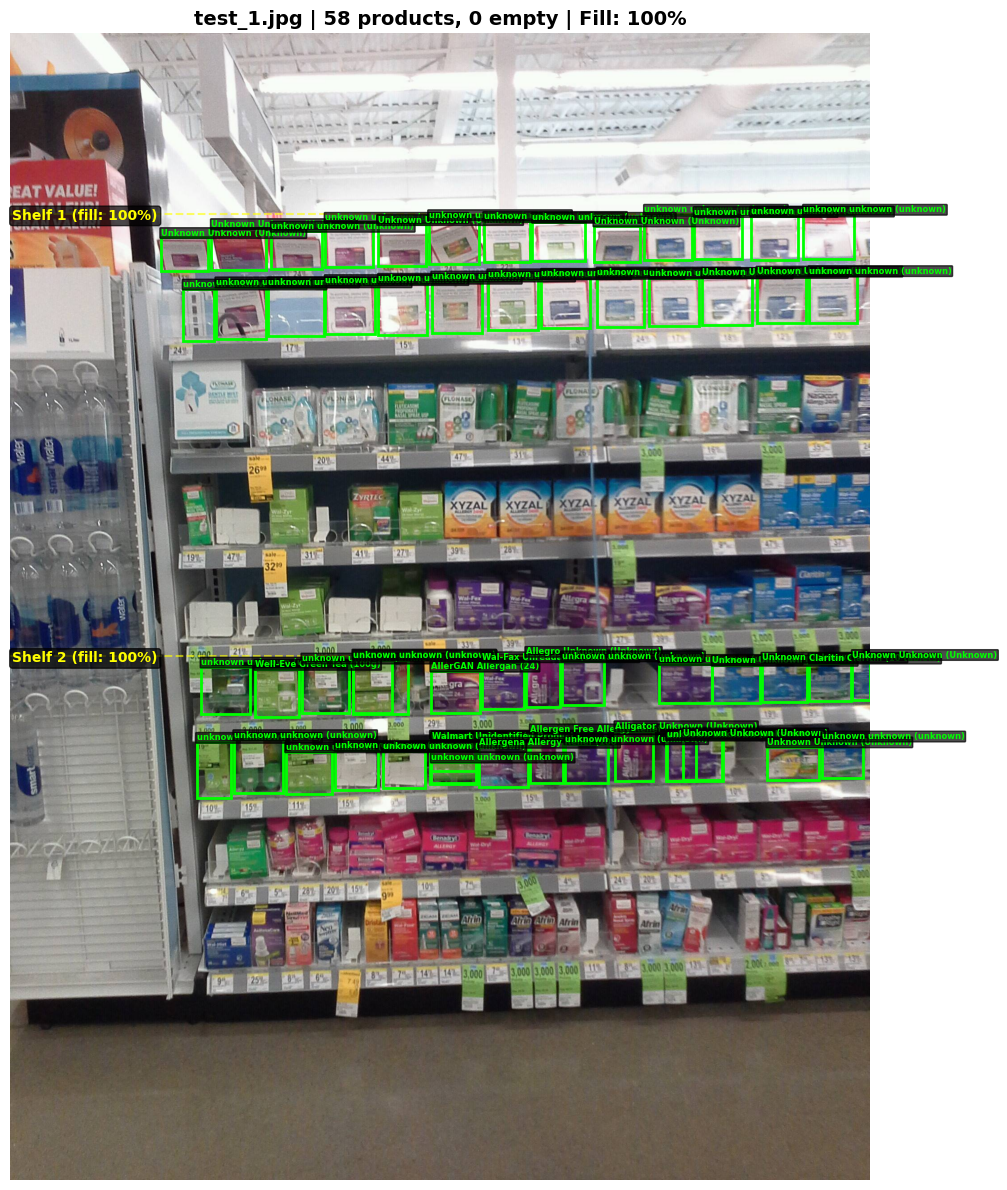

  Saved: /kaggle/working/pipeline_output/annotated_2.png


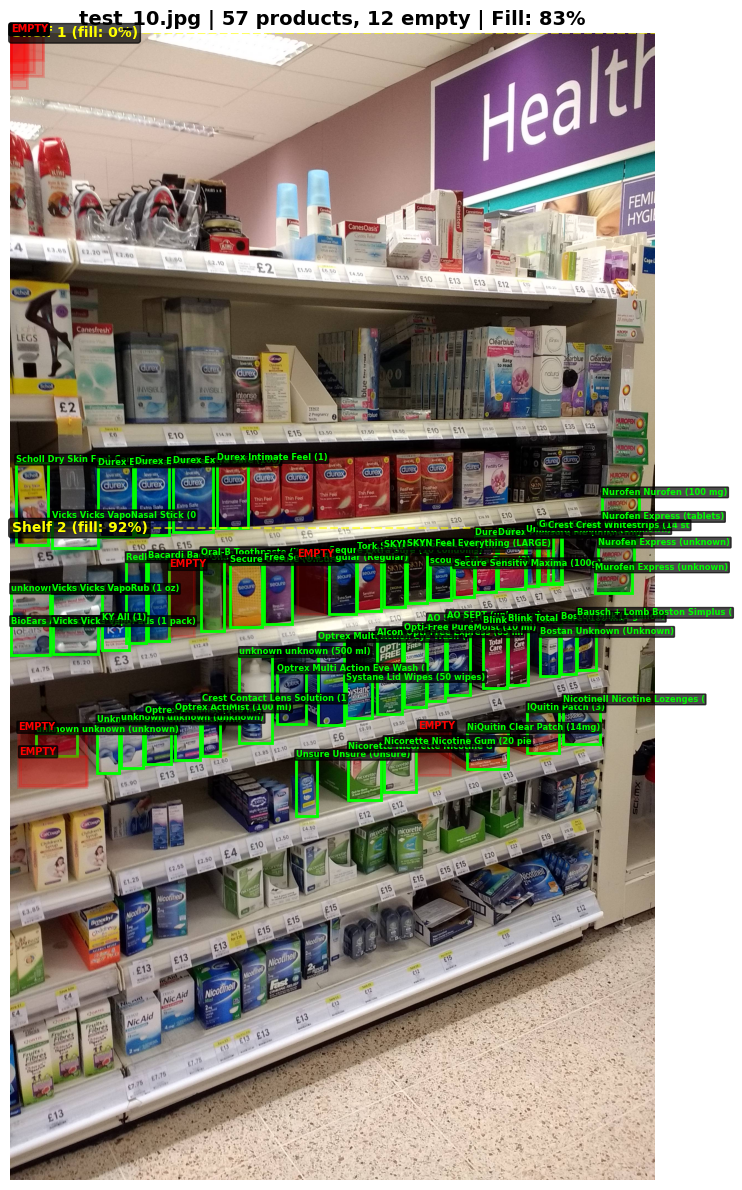

In [47]:
# ============================================================
# Cell 12: Visualize results
# ============================================================

def visualize_result(image_path, result, save_path=None):
    img = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    fig, ax = plt.subplots(figsize=(18, 12))
    ax.imshow(img)

    for shelf in result["shelves"]:
        yt = int(shelf["y_top"] * h)
        ax.axhline(y=yt, color="yellow", linewidth=1.5, linestyle="--", alpha=0.6)
        ax.text(5, yt + 14, f"Shelf {shelf['shelf_number']} (fill: {shelf['fill_rate']:.0%})",
                color="yellow", fontsize=10, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="black", alpha=0.7))

        for p in shelf["products"]:
            bx = p["bbox_px"]
            rect = patches.Rectangle((bx["x1"], bx["y1"]), bx["x2"] - bx["x1"], bx["y2"] - bx["y1"],
                                     linewidth=2, edgecolor="lime", facecolor="none")
            ax.add_patch(rect)
            label = p["name"][:30]
            ax.text(bx["x1"], bx["y1"] - 4, label, color="lime", fontsize=6,
                    fontweight="bold", bbox=dict(boxstyle="round,pad=0.1",
                    facecolor="black", alpha=0.7))

        for e in shelf["empties"]:
            bx = e["bbox_px"]
            rect = patches.Rectangle((bx["x1"], bx["y1"]), bx["x2"] - bx["x1"], bx["y2"] - bx["y1"],
                                     linewidth=2, edgecolor="red", facecolor="red", alpha=0.2)
            ax.add_patch(rect)
            ax.text(bx["x1"], bx["y1"] - 4, "EMPTY", color="red", fontsize=7,
                    fontweight="bold", bbox=dict(boxstyle="round,pad=0.1",
                    facecolor="black", alpha=0.7))

    ax.set_title(f"{result['image']} | {result['total_products']} products, "
                 f"{result['total_empty']} empty | Fill: {result['fill_rate']:.0%}",
                 fontsize=14, fontweight="bold")
    ax.axis("off")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"  Saved: {save_path}")
    plt.show()


# Visualize first 3 results
for idx, result in enumerate(all_results[:3]):
    img_path = all_shelf_images[idx]
    save_path = os.path.join(OUTPUT_DIR, f"annotated_{idx}.png")
    visualize_result(img_path, result, save_path)


In [48]:
# ============================================================
# Cell 13: Export CSV + summary
# ============================================================
rows = []
for result in all_results:
    for shelf in result["shelves"]:
        for p in shelf["products"]:
            rows.append({
                "image": result["image"],
                "shelf": shelf["shelf_number"],
                "shelf_fill_rate": shelf["fill_rate"],
                "loc_id": p["loc_id"],
                "brand": p.get("brand", ""),
                "product_name": p["name"],
                "ocr_text": p.get("ocr_text", ""),
                "llm_confidence": p.get("llm_confidence", ""),
                "status": "stocked",
                "detection_conf": p["confidence"],
                "facings": p["facings"],
                "cx": p["bbox"]["cx"], "cy": p["bbox"]["cy"],
                "w": p["bbox"]["w"], "h": p["bbox"]["h"],
            })
        for e in shelf["empties"]:
            rows.append({
                "image": result["image"],
                "shelf": shelf["shelf_number"],
                "shelf_fill_rate": shelf["fill_rate"],
                "loc_id": e["loc_id"],
                "brand": "",
                "product_name": "EMPTY",
                "ocr_text": "",
                "llm_confidence": "",
                "status": "empty",
                "detection_conf": e["confidence"],
                "facings": 0,
                "cx": e["bbox"]["cx"], "cy": e["bbox"]["cy"],
                "w": e["bbox"]["w"], "h": e["bbox"]["h"],
            })

if rows:
    csv_path = os.path.join(OUTPUT_DIR, "all_detections.csv")
    with open(csv_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=rows[0].keys())
        writer.writeheader()
        writer.writerows(rows)
    print(f"Exported {len(rows)} detections to {csv_path}")

# JSON export
json_path = os.path.join(OUTPUT_DIR, "all_results.json")
with open(json_path, "w") as f:
    json.dump(all_results, f, indent=2)
print(f"Exported JSON to {json_path}")

# Summary
if all_results:
    print(f"\n{'='*60}")
    print(f"BATCH SUMMARY")
    print(f"{'='*60}")
    print(f"Images processed:     {len(all_results)}")
    print(f"Total products found: {sum(r['total_products'] for r in all_results)}")
    print(f"Total empty spaces:   {sum(r['total_empty'] for r in all_results)}")
    print(f"Average fill rate:    {np.mean([r['fill_rate'] for r in all_results]):.1%}")
    print(f"\nOutputs saved to: {OUTPUT_DIR}")


Exported 544 detections to /kaggle/working/pipeline_output/all_detections.csv
Exported JSON to /kaggle/working/pipeline_output/all_results.json

BATCH SUMMARY
Images processed:     5
Total products found: 525
Total empty spaces:   19
Average fill rate:    95.7%

Outputs saved to: /kaggle/working/pipeline_output


---
## Pipeline Summary

| Stage | Model | What it finds | Speed on T4 |
|-------|-------|--------------|-------------|
| 1 | YOLOv8 trained on SKU-110K | Every product on the shelf | ~100ms/image |
| 2 | Custom trained YOLOv8 | Every empty space / gap | ~100ms/image |
| 3 | EasyOCR + Qwen2-VL-7B | Product name, brand, size for each detection | ~2-4s/product |

**Test image sources:**
- Default: Kaggle SKU110K annotations dataset (set `USE_ROBOFLOW = False` in Cell 4)
- Optional: Roboflow API (set `USE_ROBOFLOW = True` in Cell 4 when API key is working)

**To use your own models:** Update the paths in Cell 3 to point to your uploaded Kaggle Datasets.

**Next steps:**
- Get planogram data from MCCS mentor to enable compliance scoring
- Build product catalog lookup between OCR and Qwen2-VL for faster matching
- Add barcode detection as an additional identification signal
- Fine-tune on actual MCX product images once available
